Phase 4: Methodology and Results

In this phase, the methodology proposed in Phase 1 is implemented on the IoT Network Dataset. The objective is to classify different types of cyber attacks using machine learning techniques.

In [30]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/malaikatanveer123/iot-dataset/feature_engineered_iot_dataset.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   src_port          211043 non-null  float64
 1   dst_port          211043 non-null  float64
 2   conn_state        211043 non-null  float64
 3   label             211043 non-null  int64  
 4   type              211043 non-null  int64  
 5   dst_ip_bytes_log  211043 non-null  float64
 6   src_ip_bytes_log  211043 non-null  float64
 7   duration_log      211043 non-null  float64
 8   dst_bytes_log     211043 non-null  float64
 9   src_bytes_log     211043 non-null  float64
 10  bytes_ratio       211043 non-null  float64
 11  ip_bytes_ratio    211043 non-null  float64
 12  pkts_ratio        211043 non-null  float64
 13  total_ip_bytes    211043 non-null  float64
 14  bytes_per_pkt     211043 non-null  float64
 15  bytes_per_second  211043 non-null  float64
 16  port_sum          21

The dataset used in this phase is the feature-engineered dataset obtained from Phase 3. It contains processed and meaningful features representing network traffic behavior.

In [31]:
df.isnull().sum()

src_port            0
dst_port            0
conn_state          0
label               0
type                0
dst_ip_bytes_log    0
src_ip_bytes_log    0
duration_log        0
dst_bytes_log       0
src_bytes_log       0
bytes_ratio         0
ip_bytes_ratio      0
pkts_ratio          0
total_ip_bytes      0
bytes_per_pkt       0
bytes_per_second    0
port_sum            0
port_diff           0
cluster             0
dtype: int64

No missing values were found in the dataset. The data was already cleaned and preprocessed in previous phases.

Exploratory Data Analysis (EDA) was performed in Phase 2, where distribution of features, class imbalance, and correlations were analyzed. Key patterns in network traffic were identified.

In [32]:
X = df.drop(['type','label'], axis=1)
y = df['type']

Feature selection was performed using multiple algorithms in Phase 3. Only the most important features were retained. All categorical features were encoded into numerical form for model training.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training and testing sets to evaluate model performance on unseen data.

In [34]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier()
lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3791
[LightGBM] [Info] Number of data points in the train set: 168834, number of used features: 17
[LightGBM] [Info] Start training from score -2.351278
[LightGBM] [Info] Start training from score -2.360398
[LightGBM] [Info] Start training from score -2.352211
[LightGBM] [Info] Start training from score -2.354953
[LightGBM] [Info] Start training from score -5.315246
[LightGBM] [Info] Start training from score -1.440562
[LightGBM] [Info] Start training from score -2.354329
[LightGBM] [Info] Start training from score -2.359269
[LightGBM] [Info] Start training from score -2.357265
[LightGBM] [Info] Start training from score -2.359394


LightGBM was used as the primary model due to its efficiency and ability to handle large datasets.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Random Forest was used to compare performance with another tree-based model.

In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Logistic Regression was used as a baseline model for comparison.

In [41]:
from sklearn.metrics import accuracy_score, classification_report

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))

LightGBM Accuracy: 0.9411499917079296
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      3919
           1       0.96      0.94      0.95      4065
           2       0.97      0.88      0.92      3934
           3       0.94      0.93      0.94      3978
           4       0.43      0.51      0.47       213
           5       0.92      0.96      0.94     10021
           6       0.98      0.97      0.97      3968
           7       0.96      0.92      0.94      4047
           8       0.92      0.95      0.93      4015
           9       0.94      0.95      0.95      4049

    accuracy                           0.94     42209
   macro avg       0.90      0.90      0.90     42209
weighted avg       0.94      0.94      0.94     42209



Model performance was evaluated using accuracy, precision, recall, and F1-score.

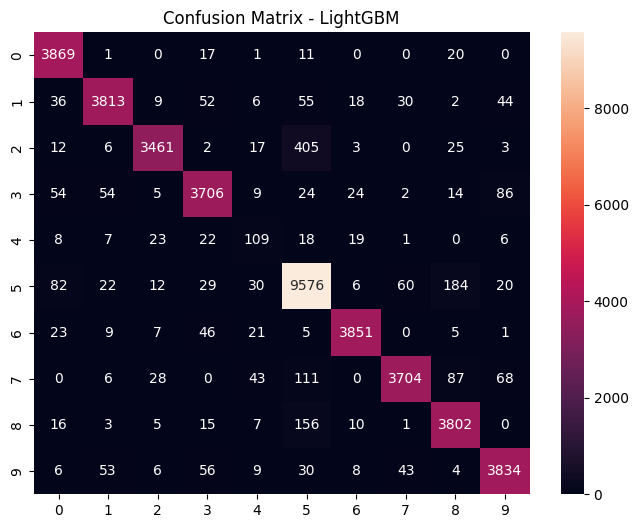

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - LightGBM")
plt.show()

The confusion matrix shows how well the model correctly classifies different attack categories.

In [43]:
import pandas as pd

importance = pd.Series(lgb.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

duration_log        3550
src_port            3030
dst_port            2647
bytes_per_second    2344
src_ip_bytes_log    2086
port_sum            2039
port_diff           2023
ip_bytes_ratio      1664
total_ip_bytes      1641
bytes_per_pkt       1498
dtype: int32

Feature importance analysis shows which features contribute most to attack detection.

In [44]:
df['attack_risk'] = lgb.predict(df.drop(['type','label'], axis=1))

An IoT Attack Risk Indicator was developed to predict the most likely attack type based on network behavior. This provides deeper insight into the nature of threats rather than only detecting malicious traffic.

In [45]:
print("LGB:", accuracy_score(y_test, y_pred_lgb))
print("RF:", accuracy_score(y_test, y_pred_rf))
print("LR:", accuracy_score(y_test, y_pred_lr))

LGB: 0.9411499917079296
RF: 0.9893861498732498
LR: 0.8973915515648322


LightGBM achieved an accuracy of 94%, while Random Forest achieved the highest accuracy of 98.9%. Logistic Regression performed comparatively lower due to its linear nature.

However, LightGBM provided a more balanced performance across all classes. One class showed lower precision and recall, likely due to class imbalance.

Overall, the models successfully classified multiple IoT attack types, achieving the project objective.

The methodology successfully achieved the project objectives. The models were able to classify multiple types of IoT attacks with good accuracy. Feature engineering and selection significantly improved model performance. The IoT Attack Risk Indicator provides valuable insights into network threats.